# Fitting spectro-polarimetric data in nDspec

In this tutorial, we will show how to fit IXPE-type spectro-polarimetry data. In nDspec, energy-dependent polarimety is handled through the Stokes parameters - from Stokes parameters, the code can then compute the energy dependence of the (folded) polarization degree and angle. 

Because the software only returns folded values, the polarization degree is additionally modulated by the detector modulation factor. For more detail on spectro-polarimetry, we encourage users to read [Kislat et al. 2015](https://ui.adsabs.harvard.edu/abs/arXiv:1409.6214).

In [1]:
import os
import gc
    
os.environ["OMP_NUM_THREADS"] = "1" 
os.environ["OPENBLAS_NUM_THREADS"] = "1" 
os.environ["MKL_NUM_THREADS"] = "1" 
os.environ["VECLIB_MAXIMUM_THREADS"] = "1" 
os.environ["NUMEXPR_NUM_THREADS"] = "1" 

import sys
import numpy as np

from lmfit import Model as LM_Model
from lmfit import CompositeModel

sys.path.append('/home/matteo/Software/nDspec/src/')

from ndspec.Response import ResponseMatrix
from ndspec.FitSpectroPolarimetry import FitSpectroPolarimetry
import ndspec.Models as models
import ndspec.XspecInterface as XSModels

## Fitting a single detector

Let us begin by analyzing the data from just one of the three detector units on board IXPE. First, we need to load two ```ResponseMatrix``` objects: one containing the ARF, which will be applied to the Stokes I parameter, and one containig the MRF, which will be applied to the Stokes Q and U parameters:

In [2]:
path = "./data/"

response = ResponseMatrix(path+"ixpe_d1_obssim_alpha075_v012.rmf",path+"ixpe_d1_obssim_gray_alpha075_v012.arf")
pol_response = ResponseMatrix(path+"ixpe_d1_obssim_alpha075_v012.rmf",path+"ixpe_d1_obssim_gray_alpha075_v012.mrf")

Arf missing, please load it
Arf loaded
Arf missing, please load it
Arf loaded


We can now define a ```FitSpectroPolarimetry``` object and load our data. We need to pass, in order, the Stokes I ```ResponseMatrix``` object, a path to the three ```pha``` files containing the Stokes I, Q and U parameters respectively, and the Stokes Q/U ```ResponseMatrix``` object

In [3]:
pol_fit_du1 = FitSpectroPolarimetry()
pol_fit_du1.set_data(response,path+"d1_stokesI.pha",path+"d1_stokesQ.pha",path+"d1_stokesU.pha",response_pol=pol_response)

/home/matteo/Software/nDspec/src/ndspec/SimpleFit.py:1552: UserWarning: WARNING: stokes keyword not found, check file format
  warnings.warn("WARNING: stokes keyword not found, check file format",


Now that our data is set up, we can restrict our analysis to the standard 2-8 $keV$ rance of IXPE and then plot our data. ```FitSpectroPolarimetry``` provides several ways to plot data and models:

```plot_data(units="stokes")```, the default, plots the Stokes parameters as a function of energy channel in separate panel. We can instead pass ```units=polarization``` to plot polarization degree (multiplied by the modulation angle, since we are dealing with folded units) and angle as a function of energy channel. Finally, ```plot_polarization_slice``` plots the same quantities, but over a 2d slice plot, rather than two separate 1d panels.

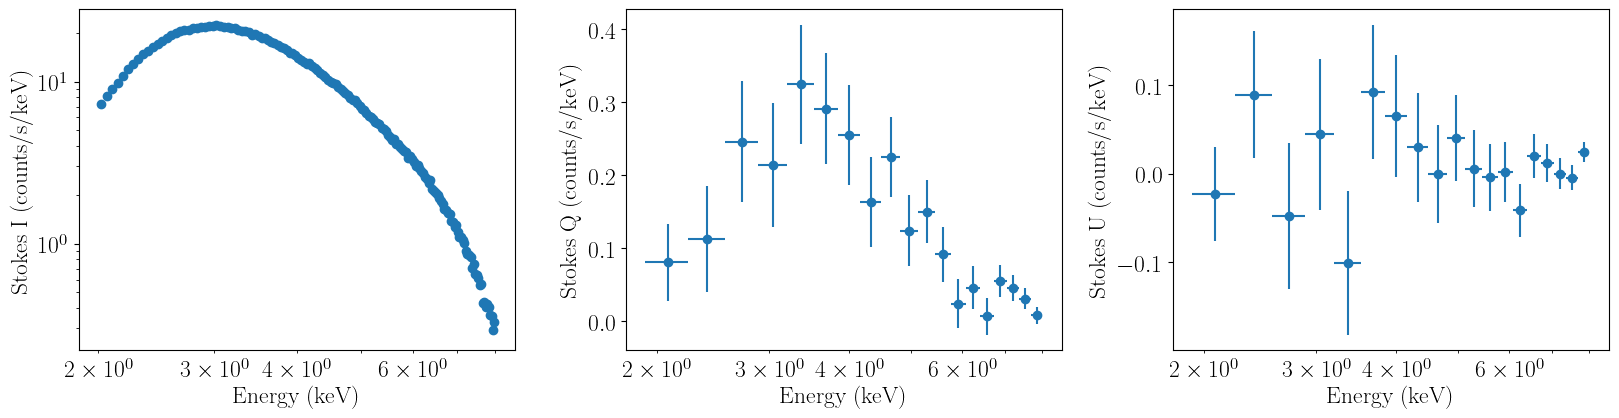

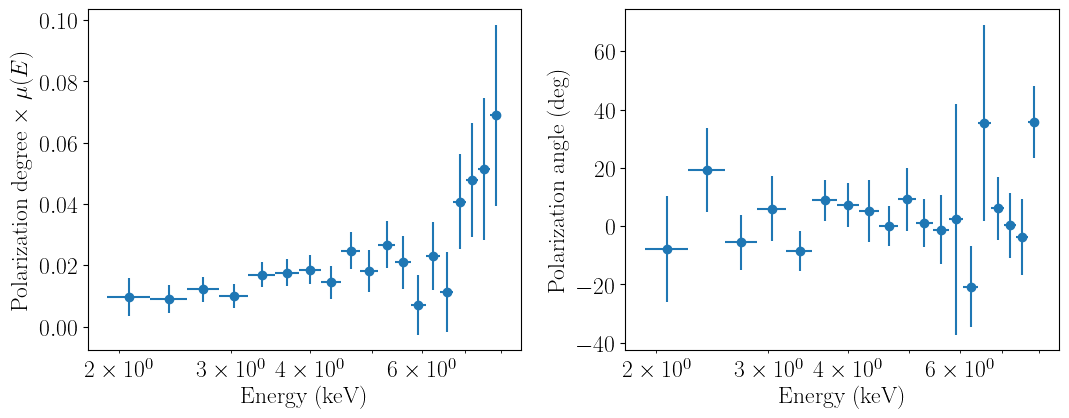

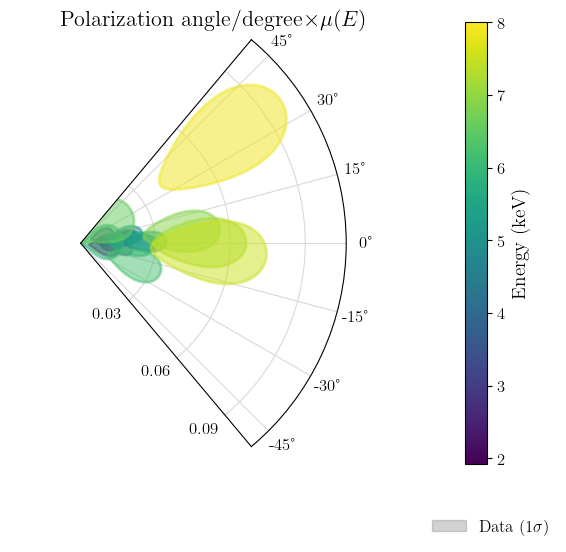

In [4]:
pol_fit_du1.ignore_energies(0.0,2.0)
pol_fit_du1.ignore_energies(8.0,30.0)
pol_fit_du1.plot_data()
pol_fit_du1.plot_data(units="polarization")
pol_fit_du1.plot_polarization_slice(plot_model=False,angle_range=(-50,50))

We can now define the models we will use in our analysis. We will use a standard Comptonization model, using the [Xspec Interface](xspec_interface.ipynb) functionality of the software, for the Stokes I component. For the polarimetry component, we will use one of the dedicated multiplicative models in nDspec, ```pol_degree_linear```, which corresponds to constant polarization angle and linearly increasing polarization degree as a function of energy.

The resulting function we will call, ```ndspec_pol_degree_linear```, returns an array of dimension $(3,\rm{n\_energs})$, where $\rm{n\_energs}$ is the number of energy bins in the IXPE response. The three rows of the model MUST contain Stokes I, Q and U parameters, in that order. 

After defining our model and parameters through standard ```lmfit``` objects, we can assign them to the data, run the fit, and plot the result:


 Solar Abundance Vector set to angr:  Anders E. & Grevesse N. Geochimica et Cosmochimica Acta 53, 197 (1989)
 Cross Section Table set to vern:  Verner, Ferland, Korista, and Yakovlev 1996
Initialized Xspec models:
nthcomp:
  type: add
  function called: C_nthcomp
  parameters:
    Gamma: value: 1.7, min: 1.001, max: 10.0, unit: n/a
    kT_e: value: 100.0, min: 1.0, max: 1000.0, unit: keV
    kT_bb: value: 0.1, min: 0.001, max: 10.0, unit: keV
    inp_type: value: 0.0, min: 0.0, max: 1.0, unit: 0/1
    Redshift: value: 0.0, min: -0.999, max: 10.0, unit: n/a
    norm: value: 1, min: 0, max: 1e+20, unit: n/a

-----------------------
(Model(ndspec_nthcomp) * Model(ndspec_pol_degree_linear))
-----------------------
Parameters
-----------------------
Name             Value      Min      Max   Stderr     Vary     Expr Brute_Step
Gamma             1.65      1.1        4     None     True     None     None
degree_slope         0      -20       20     None     True     None     None
energ_pivot

/home/matteo/.local/lib/python3.8/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


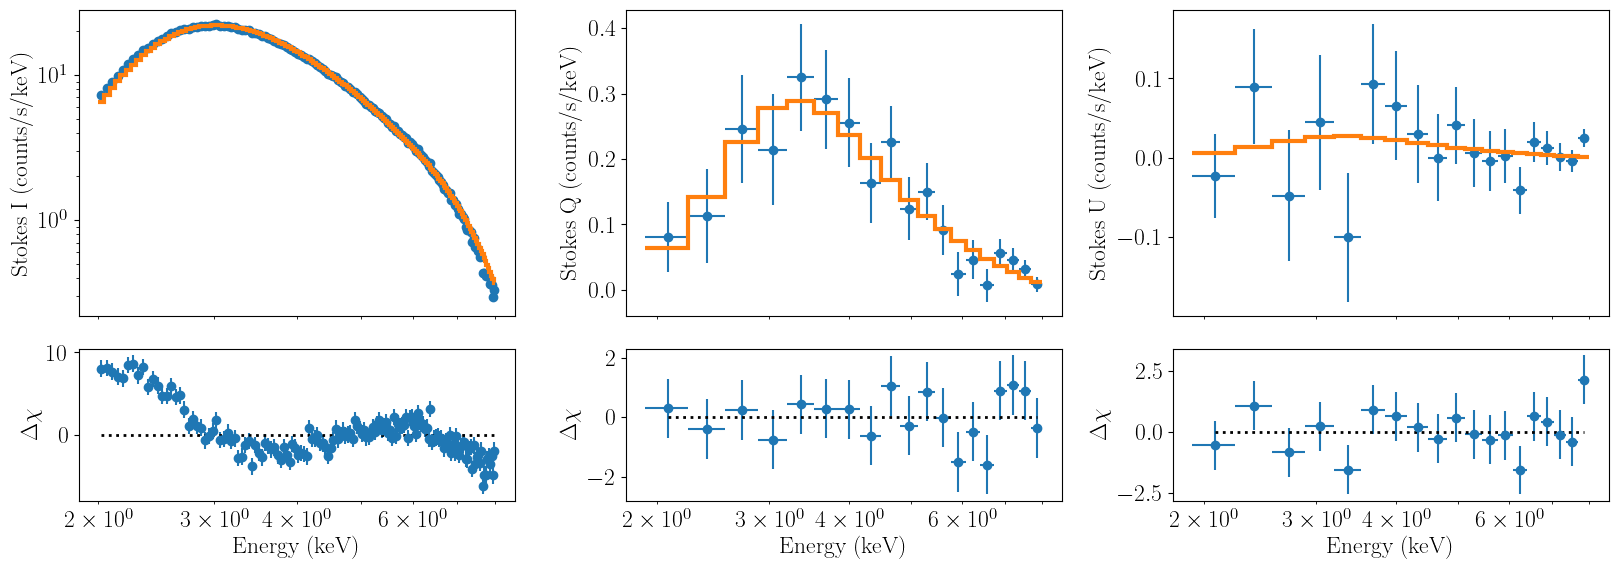

In [5]:
model_library = XSModels.FortranInterface()

def nthcomp(ear, params):
    pass

#this call actually loads the models in the library
model_library.load_models({
    "nthcomp": nthcomp
})

model_library.print_model_info()

#finally, we can write a set of wrappers in order to evaluate each model; these will be called through LMFit
def ndspec_nthcomp(ear,Gamma,kT_e,kT_bb,norm_comp):
    #wfor nthcomp, set the input type and redshift to default
    par_array = np.array([Gamma,kT_e,kT_bb,1,0,norm_comp])
    model = model_library.nthcomp(ear,par_array)
    return model

def ndspec_pol_degree_linear(energ,pol_degree,degree_slope,pol_angle,energ_pivot):
    par_array = np.array([pol_degree,degree_slope,pol_angle,energ_pivot])
    model = models.pol_degree_linear(energ,par_array)
    return model

polarization_model = LM_Model(ndspec_pol_degree_linear)

total_model = (LM_Model(ndspec_nthcomp))*polarization_model

#freeze the disk and electron temperatures because they are not constrained by this data
start_params = total_model.make_params(
               Gamma=dict(value=1.65,min=1.1,max=4.0),
               kT_e=dict(value=100,min=50,max=150,vary=False),
               kT_bb=dict(value=0.25,min=0.10,max=1,vary=False),
               norm_comp=dict(value=6.5,min=1e-1,max=50.),
               pol_degree=dict(value=0.02,min=0.0,max=1.0),
               pol_angle=dict(value=10.0,min=-90.,max=90.),
               degree_slope=dict(value=0.0,min=-20.,max=20.,vary=True),
               energ_pivot=dict(value=2.0,vary=False))

pol_fit_du1.set_model(total_model,params=start_params)
pol_fit_du1.print_model()
pol_fit_du1.print_fit_stat()

pol_fit_du1.fit_data()
pol_fit_du1.plot_model(units="stokes")

It appears that our model does a decent job of reproducing Stokes Q and U, but it is completely off in Stokes I. In addition, the value of the photon index ```Gamma``` is surprising - we find $2.2$, but the data we are analyzing comes from a hard state X-ray binary, so we would expect ```Gamma```$<1.9$. 

This is a common problem with IXPE data, and is caused by incorrect gain calibration. Just like the Xspec ```gain fit``` command (or its equivalent in ISIS), this must be accounted for in our fit. We do this thanks to the ```set_gain``` feature, which includes a model component to vary the instrument gain through the ```apply_gain``` function provided by a ```ResponseMatrix``` object. More information on the implementation of the gain correction is found in the [response optimization notebook](response_optimization.ipynb#Instrument-gain). 

No, when we call the ```pretty_print``` method, the gain parameters are included in the list and will vary during the fit. Alternatively, we can fix them to some number and freeze them, just like any other parameter, if we choose to.

In [6]:
#we add a label to our gain model to distinguish it from the gain model components of the other two detectors, later
pol_fit_du1.set_gain(slope=0.94,offset=-0.1,vary=True,label="du1")
pol_fit_du1.model_params.pretty_print()

Name                Value      Min      Max   Stderr     Vary     Expr Brute_Step
Gamma               2.194      1.1        4   0.0132     True     None     None
degree_slope     0.003292      -20       20 0.007982     True     None     None
energ_pivot             2     -inf      inf        0    False     None     None
gain_offset_du1      -0.1     -0.3      0.3     None     True     None     None
gain_slope_du1       0.94      0.9      1.1     None     True     None     None
kT_bb                0.25      0.1        1        0    False     None     None
kT_e                  100       50      150        0    False     None     None
norm_comp              50      0.1       50   0.8982     True     None     None
pol_angle           2.655      -90       90    6.878     True     None     None
pol_degree        0.02989        0        1  0.01964     True     None     None


And now, when we run our fit, we find that the model matches the data very well, and that the photon index is much more sensible.

-----------------------
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 1182
    # data points      = 188
    # variables        = 7
    fit statistic      = 157.5920102540943
    reduced statistic  = 0.870674089801626
    Akaike info crit   = -19.16930681312624
    Bayesian info crit = 3.485786926683403
[[Parameters]]
    Gamma:            1.92650242 +/- 0.00788978 (0.41%) (init = 2.194437), model_value = 1.926502
    kT_e:             100 (fixed)
    kT_bb:            0.25 (fixed)
    norm_comp:        36.6927512 +/- 0.31787416 (0.87%) (init = 49.99848), model_value = 36.69275
    pol_degree:       0.02824672 +/- 0.00691358 (24.48%) (init = 0.02989351), model_value = 0.02824672
    degree_slope:     0.00355311 +/- 0.00269445 (75.83%) (init = 0.003291988), model_value = 0.003553109
    pol_angle:        2.57431849 +/- 2.40687631 (93.50%) (init = 2.655179), model_value = 2.574318
    energ_pivot:      2 (fixed)
    gain_slope_du1:   0.96280082 +/- 0.0016837

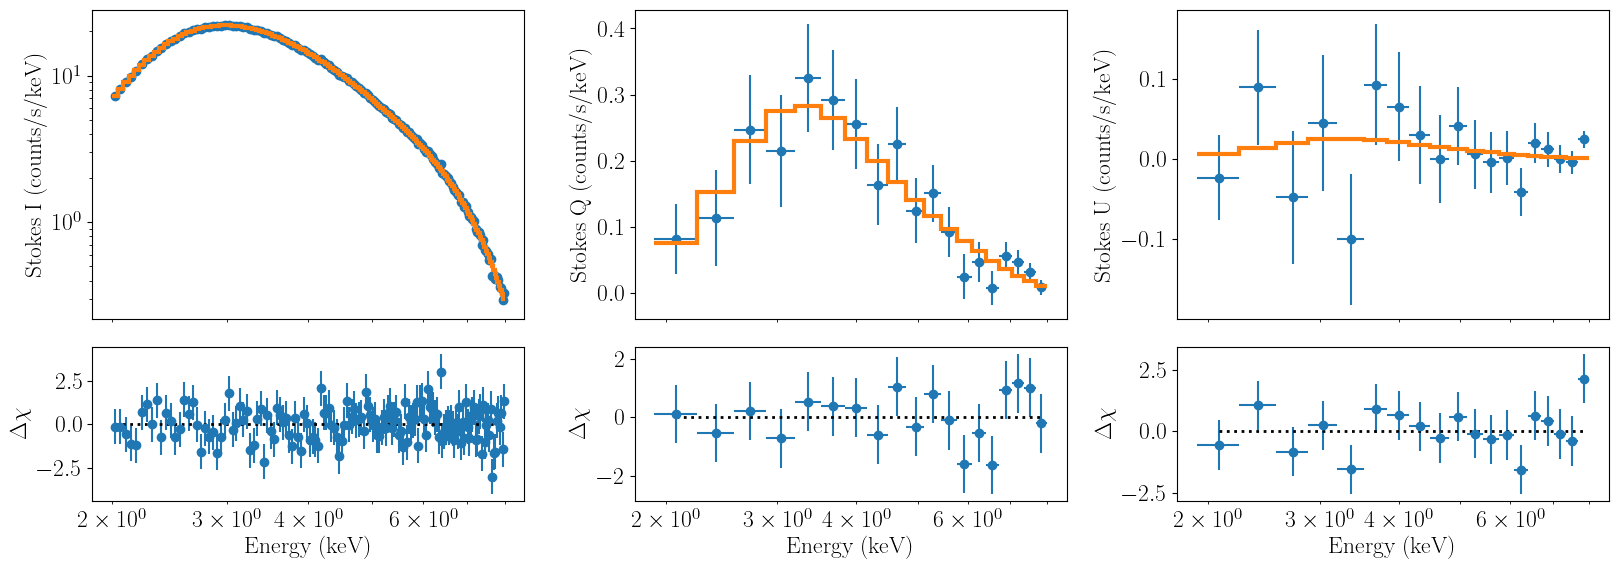

In [7]:
pol_fit_du1.fit_data()
pol_fit_du1.plot_model(units="stokes")

Now that we know we can make sense of the data from one of the detectors, we want to model all three jointly. We will do this by going through the same set up as earlier: we define a fitter object to contain the data from each DU, load a model and data, define the energy range we want to include, and enable the gain correction.

Note that our polarization model is going to be slightly different. Because the three detectors are not perfectly cross-calibrated, we include an additional normalization factor for the Stokes I parameter. This is identical to the standard constant factor used when analyzing multiple detectors.

In [8]:
#new model to renormalize stokes I 
def ndspec_pol_degree_linear_renormd2(energ,pol_degree,degree_slope,pol_angle,energ_pivot,renorm_d2):
    par_array = np.array([pol_degree,degree_slope,pol_angle,energ_pivot])
    model = models.pol_degree_linear(energ,par_array)
    model[0] *= renorm_d2
    return model

polarization_model = LM_Model(ndspec_pol_degree_linear_renormd2)

total_model = (LM_Model(ndspec_nthcomp))*polarization_model

start_params = total_model.make_params(
               Gamma=dict(value=1.65,min=1.1,max=4.0),
               kT_e=dict(value=100,min=50,max=150,vary=False),
               kT_bb=dict(value=0.25,min=0.10,max=1,vary=False),
               norm_comp=dict(value=6.5,min=1e-1,max=50.),
               pol_degree=dict(value=0.02,min=0.0,max=1.0),
               pol_angle=dict(value=10.0,min=-90.,max=90.),
               degree_slope=dict(value=0.0,min=-20.,max=20.,vary=True),
               energ_pivot=dict(value=2.0,vary=False),
               renorm_d2=dict(value=1.0,min=0.5,max=1.5,vary=True))

response2 = ResponseMatrix(path+"ixpe_d2_obssim_alpha075_v012.rmf",path+"ixpe_d2_obssim_gray_alpha075_v012.arf")
pol_response2 = ResponseMatrix(path+"ixpe_d2_obssim_alpha075_v012.rmf",path+"ixpe_d2_obssim_gray_alpha075_v012.mrf")
pol_fit_du2 = FitSpectroPolarimetry()
pol_fit_du2.set_data(response,path+"d2_stokesI.pha",path+"d2_stokesQ.pha",path+"d2_stokesU.pha",response_pol=pol_response)
pol_fit_du2.ignore_energies(0.0,2.0)
pol_fit_du2.ignore_energies(8.0,30.0)
pol_fit_du2.set_model(total_model,params=start_params)
pol_fit_du2.set_gain(slope=0.94,offset=-0.1,vary=True,label="du2")
pol_fit_du2.model_params.pretty_print()

Arf missing, please load it
Arf loaded
Arf missing, please load it
Arf loaded
Name                Value      Min      Max   Stderr     Vary     Expr Brute_Step
Gamma                1.65      1.1        4     None     True     None     None
degree_slope            0      -20       20     None     True     None     None
energ_pivot             2     -inf      inf     None    False     None     None
gain_offset_du2      -0.1     -0.3      0.3     None     True     None     None
gain_slope_du2       0.94      0.9      1.1     None     True     None     None
kT_bb                0.25      0.1        1     None    False     None     None
kT_e                  100       50      150     None    False     None     None
norm_comp             6.5      0.1       50     None     True     None     None
pol_angle              10      -90       90     None     True     None     None
pol_degree           0.02        0        1     None     True     None     None
renorm_d2               1      0.5      

/home/matteo/Software/nDspec/src/ndspec/SimpleFit.py:1552: UserWarning: WARNING: stokes keyword not found, check file format
  warnings.warn("WARNING: stokes keyword not found, check file format",


In [9]:
def ndspec_pol_degree_linear_renormd3(energ,pol_degree,degree_slope,pol_angle,energ_pivot,renorm_d3):
    par_array = np.array([pol_degree,degree_slope,pol_angle,energ_pivot])
    model = models.pol_degree_linear(energ,par_array)
    model[0] *= renorm_d3
    return model

polarization_model = LM_Model(ndspec_pol_degree_linear_renormd3)

total_model = (LM_Model(ndspec_nthcomp))*polarization_model

start_params = total_model.make_params(
               Gamma=dict(value=1.65,min=1.1,max=4.0),
               kT_e=dict(value=100,min=50,max=150,vary=False),
               kT_bb=dict(value=0.25,min=0.10,max=1,vary=False),
               norm_comp=dict(value=6.5,min=1e-1,max=50.),
               pol_degree=dict(value=0.02,min=0.0,max=1.0),
               pol_angle=dict(value=10.0,min=-90.,max=90.),
               degree_slope=dict(value=0.0,min=-20.,max=20.,vary=True),
               energ_pivot=dict(value=2.0,vary=False),
               renorm_d3=dict(value=1.0,min=0.5,max=1.5,vary=True))

response3 = ResponseMatrix(path+"ixpe_d3_obssim_alpha075_v012.rmf",path+"ixpe_d3_obssim_gray_alpha075_v012.arf")
pol_response3 = ResponseMatrix(path+"ixpe_d3_obssim_alpha075_v012.rmf",path+"ixpe_d3_obssim_gray_alpha075_v012.mrf")
pol_fit_du3 = FitSpectroPolarimetry()
pol_fit_du3.set_data(response,path+"d3_stokesI.pha",path+"d3_stokesQ.pha",path+"d3_stokesU.pha",response_pol=pol_response)
pol_fit_du3.ignore_energies(0.0,2.0)
pol_fit_du3.ignore_energies(8.0,30.0)
pol_fit_du3.set_model(total_model,params=start_params)
pol_fit_du3.set_gain(slope=0.94,offset=-0.1,vary=True,label="du3")
pol_fit_du3.model_params.pretty_print()

Arf missing, please load it
Arf loaded
Arf missing, please load it
Arf loaded
Name                Value      Min      Max   Stderr     Vary     Expr Brute_Step
Gamma                1.65      1.1        4     None     True     None     None
degree_slope            0      -20       20     None     True     None     None
energ_pivot             2     -inf      inf     None    False     None     None
gain_offset_du3      -0.1     -0.3      0.3     None     True     None     None
gain_slope_du3       0.94      0.9      1.1     None     True     None     None
kT_bb                0.25      0.1        1     None    False     None     None
kT_e                  100       50      150     None    False     None     None
norm_comp             6.5      0.1       50     None     True     None     None
pol_angle              10      -90       90     None     True     None     None
pol_degree           0.02        0        1     None     True     None     None
renorm_d3               1      0.5      

## Joint fitting all IXPE detectors

Now that our individual fitter objects are ready, we can set up a ```JointFit``` object to model everything together, just like in the [joint fitting notebook](fit_joint.ipynb). Note that in nDspec, parameters with identical names from different fitters are assumed to map to the same physical quantity (e.g. the photon index), so they are shared automatically in a joint fit. In our case, the only parameters which apply separately to each IXPE detector are the gain calibration, and the Stokes I re-normalization.

In [10]:
from ndspec.JointFit import JointFit

ixpe_joint = JointFit()
ixpe_joint.add_fitobj(pol_fit_du1,"du1")
ixpe_joint.add_fitobj(pol_fit_du2,"du2")
ixpe_joint.add_fitobj(pol_fit_du3,"du3")
ixpe_joint.model_params.pretty_print()

The following parameters have been shared: ['Gamma', 'kT_e', 'kT_bb', 'norm_comp', 'pol_degree', 'degree_slope', 'pol_angle', 'energ_pivot']
The following parameters have been shared: ['Gamma', 'kT_e', 'kT_bb', 'norm_comp', 'pol_degree', 'degree_slope', 'pol_angle', 'energ_pivot']
Name                Value      Min      Max   Stderr     Vary     Expr Brute_Step
Gamma               1.927      1.1        4  0.00789     True     None     None
degree_slope     0.003553      -20       20 0.002694     True     None     None
energ_pivot             2     -inf      inf        0    False     None     None
gain_offset_du1   0.01518     -0.3      0.3  0.00377     True     None     None
gain_offset_du2      -0.1     -0.3      0.3     None     True     None     None
gain_offset_du3      -0.1     -0.3      0.3     None     True     None     None
gain_slope_du1     0.9628      0.9      1.1 0.001684     True     None     None
gain_slope_du2       0.94      0.9      1.1     None     True     None     N

Now that the joint fitter is ready, we can simply fit the data normally, and then plot the result of the full fit. Once again, thanks to the gain correction we recover a good fit statistic and can model all three Stokes parameters across all three detectors.

In [11]:
ixpe_joint.fit_data()

-----------------------
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 380
    # variables        = 13
-----------------------
    Dataset: du1
    fit statistic      = 164.64648180662294
    reduced statistic  = 0.9408370388949883
    # data points      = 188
    Dataset: du2
    fit statistic      = 198.21396434432182
    reduced statistic  = 1.0061622555549332
    # data points      = 210
    Dataset: du3
    fit statistic      = 200.099503036685
    reduced statistic  = 1.0157335179527158
    # data points      = 210
-----------------------
    total fit stat         = 562.9599491876297
    total reduced stat     = 0.94615117510526
    total data points      = 608
-----------------------
[[Parameters]]
    Gamma:            1.83830434 +/- 0.00697793 (0.38%) (init = 1.926502)
    kT_e:             100 (fixed)
    kT_bb:            0.25 (fixed)
    norm_comp:        32.8962034 +/- 0.25584476 (0.78%) (init = 36.69275)
    pol_degree:       0.03197213 +/- 

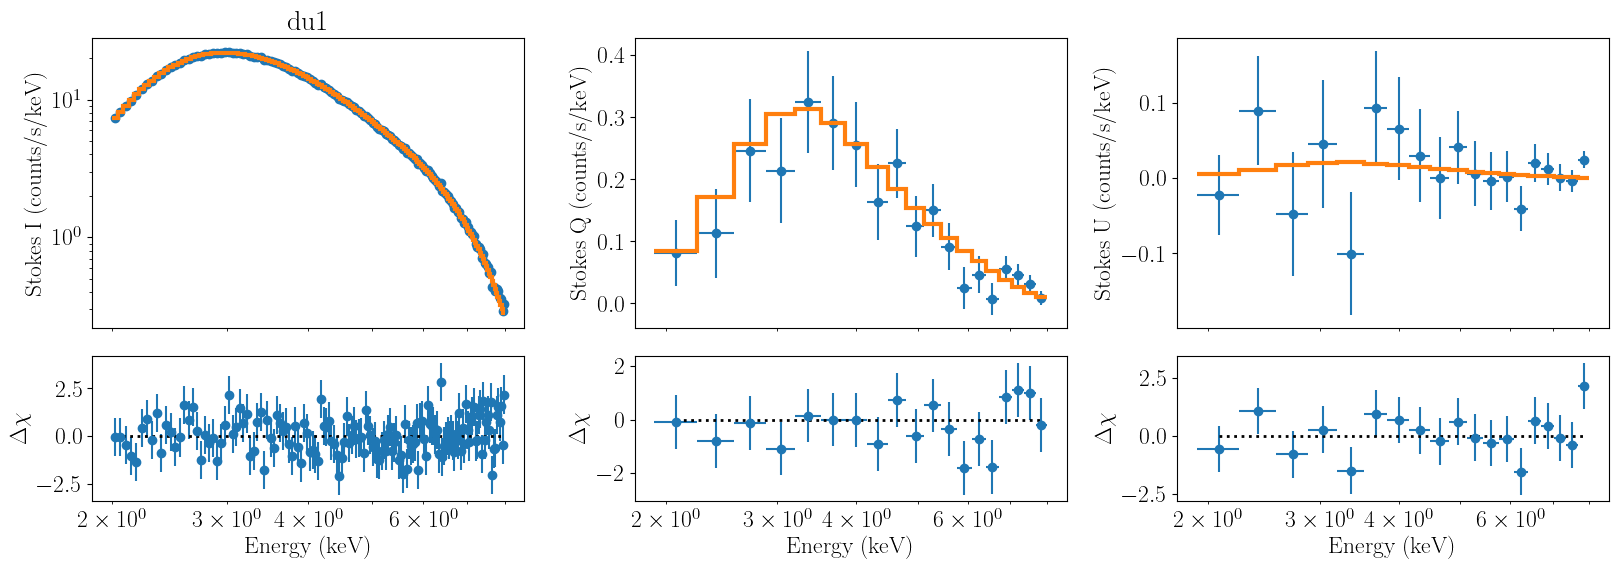

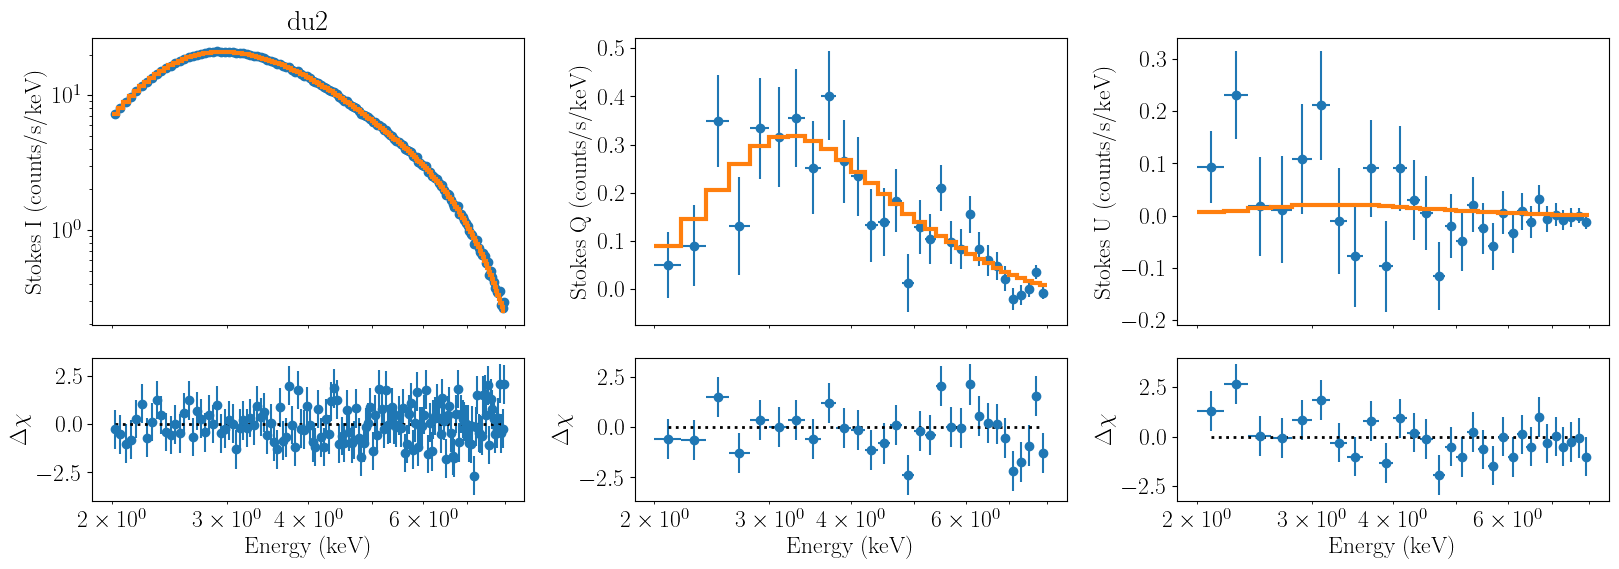

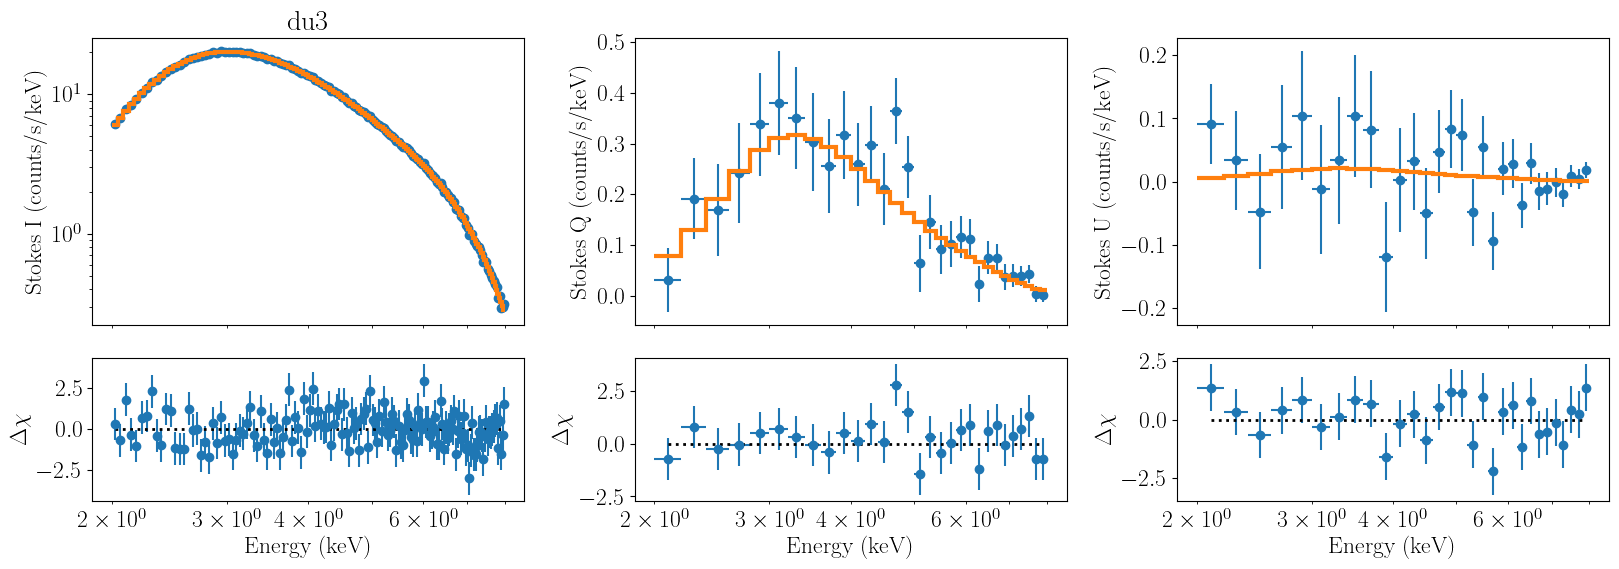

In [12]:
ixpe_joint.all_plots(units="stokes")